# Ensemble Model (Random Forest Bagging) with Deployment - Heart Disease Prediction
**Name:** Raj koli  |  **Roll No:** 150096724145  
**Course:** BTech ElonMusk 2428 - Machine Learning  
**Assignment:** Assignment 10 - Building Ensemble Model With Deployment  

**Dataset:** Heart Disease Dataset (`heart.csv`) - 303 patient records, 13 clinical features, binary target (0 = No Disease, 1 = Heart Disease)  
**Kaggle Link:** https://www.kaggle.com/datasets/ronitf/heart-disease-uci  
**Model:** Random Forest Classifier = **Bagging ensemble** (aggregating diverse decision trees trained on bootstrap samples with random feature selection).  
**Deployment:** Interactive Streamlit web application (`app.py`) for clinical decision support.


## Step 1: Import Libraries and Load Dataset
Load the UCI Heart Disease dataset and preview the first 5 records.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

# Load dataset
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Step 2: Understand and Inspect the Data
Check dimensions, missing values, data types, and target class distribution.

In [2]:
print('Dataset Shape:', df.shape)
print('Total Missing Values:', df.isnull().sum().sum())
print('\nTarget Class Distribution (0 = No Disease, 1 = Heart Disease):')
print(df['target'].value_counts())
print('\nSummary Statistics:')
df.describe()

Dataset Shape: (303, 14)
Total Missing Values: 0

Target Class Distribution (0 = No Disease, 1 = Heart Disease):
target
1    165
0    138
Name: count, dtype: int64

Summary Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Step 3: Prepare Features (X) and Target (y)
Separate the 13 clinical feature columns from the binary target variable.

In [3]:
X = df.drop(columns=['target'])
y = df['target']

print('Feature Matrix Shape:', X.shape)
print('Target Vector Shape:', y.shape)
print('Feature Columns:', list(X.columns))

Feature Matrix Shape: (303, 13)
Target Vector Shape: (303,)
Feature Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## Step 4: Stratified Train-Test Split (80/20)
Split data into 80% training and 20% testing sets with stratification to preserve class balance.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training Set:', X_train.shape, '| Testing Set:', X_test.shape)
print('Train Class Ratio:\n', y_train.value_counts(normalize=True))
print('Test Class Ratio:\n', y_test.value_counts(normalize=True))

Training Set: (242, 13) | Testing Set: (61, 13)
Train Class Ratio:
 target
1    0.545455
0    0.454545
Name: proportion, dtype: float64
Test Class Ratio:
 target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


## Step 5: Build and Train the Random Forest Bagging Ensemble
Random Forest is a bagging ensemble technique that builds 100 decision trees on bootstrap samples and aggregates their predictions by majority voting.

In [5]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42,
    oob_score=True
)

# Train ensemble model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]
print('Random Forest model trained successfully!')

Random Forest model trained successfully!


## Step 6: Evaluate Model Performance
Evaluate test accuracy, 5-fold cross-validation, Out-of-Bag (OOB) score, and detailed classification metrics.

In [6]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cv_scores = cross_val_score(rf_model, X, y, cv=5)

print(f'Test Accuracy: {acc * 100:.2f} %')
print(f'5-Fold Cross-Validation Accuracy: {cv_scores.mean() * 100:.2f} % (± {cv_scores.std() * 100:.2f} %)')
print(f'Out-of-Bag (OOB) Score: {rf_model.oob_score_ * 100:.2f} %')
print(f'Precision: {prec * 100:.2f} %')
print(f'Recall (Sensitivity): {rec * 100:.2f} %')
print(f'F1-Score: {f1 * 100:.2f} %')
print(f'ROC-AUC Score: {roc_auc:.4f}')
print('\n' + '='*55)
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

Test Accuracy: 85.25 %
5-Fold Cross-Validation Accuracy: 81.83 % (± 4.39 %)
Out-of-Bag (OOB) Score: 80.99 %
Precision: 80.00 %
Recall (Sensitivity): 96.97 %
F1-Score: 87.67 %
ROC-AUC Score: 0.9286

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.95      0.71      0.82        28
Heart Disease       0.80      0.97      0.88        33

     accuracy                           0.85        61
    macro avg       0.88      0.84      0.85        61
 weighted avg       0.87      0.85      0.85        61



## Step 7: Confusion Matrix Heatmap
Visualize true positives, true negatives, false positives, and false negatives.

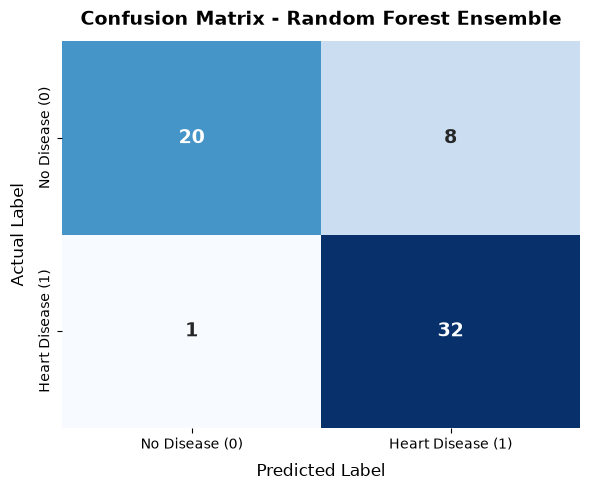

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['No Disease (0)', 'Heart Disease (1)'],
    yticklabels=['No Disease (0)', 'Heart Disease (1)'],
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('Confusion Matrix - Random Forest Ensemble', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', fontsize=12, labelpad=8)
plt.ylabel('Actual Label', fontsize=12, labelpad=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

## Step 8: ROC Curve & AUC Score
Evaluate the trade-off between True Positive Rate (Sensitivity) and False Positive Rate across all classification thresholds.

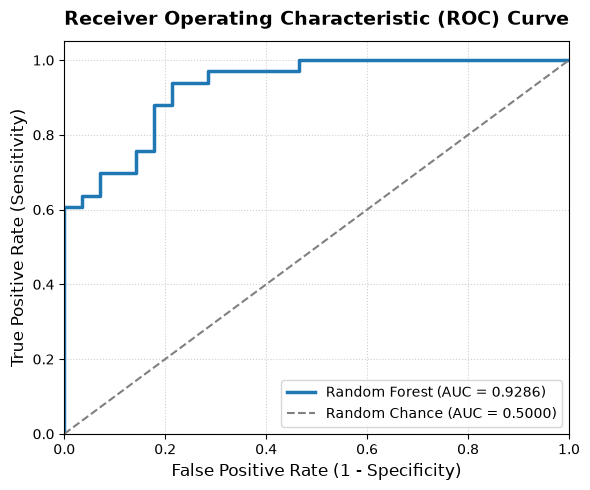

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Chance (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', pad=12)
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

## Step 9: Feature Importance Analysis
Determine the contribution of each clinical feature to the ensemble decision-making process based on Gini impurity reduction.

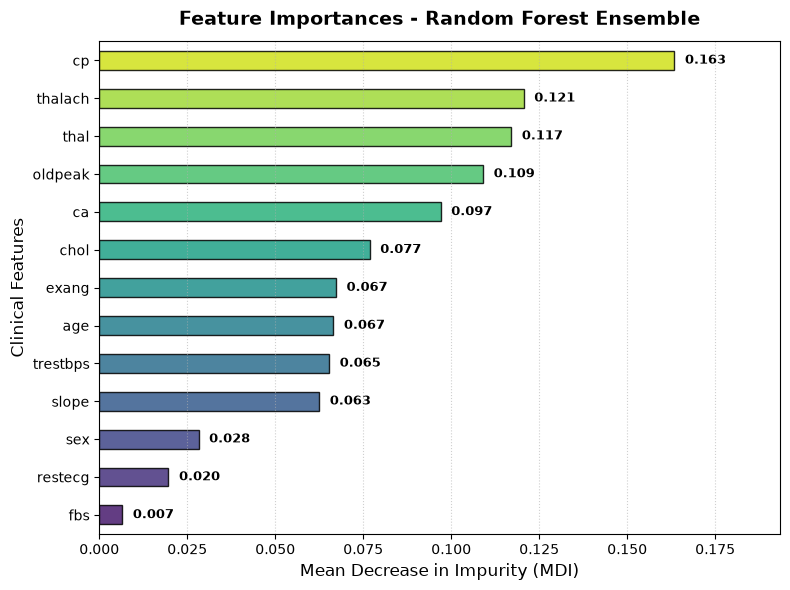

In [9]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = sns.color_palette('viridis', len(importances))
importances.plot(kind='barh', color=colors, edgecolor='black', alpha=0.85)
plt.title('Feature Importances - Random Forest Ensemble', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Mean Decrease in Impurity (MDI)', fontsize=12)
plt.ylabel('Clinical Features', fontsize=12)
for index, value in enumerate(importances):
    plt.text(value + 0.003, index, f'{value:.3f}', va='center', fontsize=9, fontweight='bold')
plt.xlim(0, max(importances) + 0.03)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

## Step 10: Comparison: Single Decision Tree vs. Bagging Random Forest
Demonstrate how bagging ensemble reduces variance and enhances generalization performance over an individual decision tree.

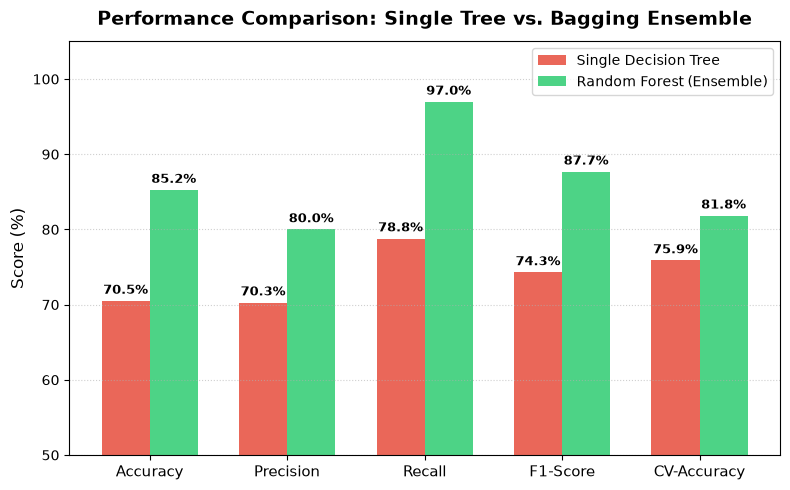

,Metric,Single Decision Tree,Random Forest Ensemble
0,Test Accuracy,70.49%,85.25%
1,Precision,70.27%,80.00%
2,Recall,78.79%,96.97%
3,F1-Score,74.29%,87.67%
4,ROC-AUC,0.6975,0.9286
5,5-Fold CV Accuracy,75.87%,81.83%


In [10]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

comparison_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', '5-Fold CV Accuracy'],
    'Single Decision Tree': [
        f'{accuracy_score(y_test, dt_pred)*100:.2f}%',
        f'{precision_score(y_test, dt_pred)*100:.2f}%',
        f'{recall_score(y_test, dt_pred)*100:.2f}%',
        f'{f1_score(y_test, dt_pred)*100:.2f}%',
        f'{roc_auc_score(y_test, dt_prob):.4f}',
        f'{cross_val_score(dt_model, X, y, cv=5).mean()*100:.2f}%'
    ],
    'Random Forest Ensemble': [
        f'{acc*100:.2f}%',
        f'{prec*100:.2f}%',
        f'{rec*100:.2f}%',
        f'{f1*100:.2f}%',
        f'{roc_auc:.4f}',
        f'{cv_scores.mean()*100:.2f}%'
    ]
})

# Comparison plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV-Accuracy']
dt_vals = [
    accuracy_score(y_test, dt_pred)*100,
    precision_score(y_test, dt_pred)*100,
    recall_score(y_test, dt_pred)*100,
    f1_score(y_test, dt_pred)*100,
    cross_val_score(dt_model, X, y, cv=5).mean()*100
]
rf_vals = [
    acc*100,
    prec*100,
    rec*100,
    f1*100,
    cv_scores.mean()*100
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, dt_vals, width, label='Single Decision Tree', color='#e74c3c', alpha=0.85)
rects2 = ax.bar(x + width/2, rf_vals, width, label='Random Forest (Ensemble)', color='#2ecc71', alpha=0.85)

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Performance Comparison: Single Tree vs. Bagging Ensemble', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(50, 105)
ax.legend(frameon=True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

for p in rects1 + rects2:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

comparison_df

## Step 11: Serialize and Save the Trained Model
Save the final Random Forest model to disk using joblib for web application deployment.

In [11]:
# Save trained model to disk
model_path = 'heart_disease_model.pkl'
joblib.dump(rf_model, model_path)
print(f'Model successfully serialized and saved as "{model_path}"')

Model successfully serialized and saved as "heart_disease_model.pkl"


## Step 12: Deployment with Streamlit (`app.py`)
The model is integrated into an interactive web application built with Streamlit for real-time patient risk evaluation.

In [12]:
# Display app code structure
with open('app.py', 'r') as f:
    app_code = f.read()

print('Streamlit App Code Length:', len(app_code), 'characters')
print('\nPreview of app.py:\n')
print('\n'.join(app_code.split('\n')[:25]))

Streamlit App Code Length: 4607 characters

Preview of app.py:

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Page configuration
st.set_page_config(
    page_title="Heart Disease Predictor",
    page_icon="❤️",
    layout="wide"
)

# Load trained model
@st.cache_resource
def load_model():
    return joblib.load('heart_disease_model.pkl')

model = load_model()

# Header
st.title("❤️ Heart Disease Prediction App")
st.markdown("""
This application uses an **Ensemble Random Forest Classifier** trained on the UCI Heart Disease dataset 
to assess the risk of coronary heart disease based on clinical patient parameters.
""")
